# Проект: семантический поиск товаров по текстовому запросу

**Автор проекта:** Александр Рогов

**Ваша роль.** Вы специалист по Data Science. Компания развивает онлайн-каталог товаров, и сейчас руководству кажется, что классический поиск по ключевым словам плохо справляется с реальными запросами. Пользователи пишут названия с ошибками, кириллицей, используют просторечные слова, ищут товары по назначению, а не по функциональности («удобные кроссовки для бега» вместо «мужские спортивные кроссовки с амортизацией»). Команда хочет проверить, поможет ли векторный поиск улучшить качество поисковой системы.

**Задача.** Вам нужно построить MVP системы семантического поиска, сравнить его с лексической baseline-моделью на подготовленной разметке и дать бизнесу обоснованную рекомендацию о том, где новое решение помогает, где ошибается и стоит ли его вообще внедрять.

## Данные

| Файл | Что это | Когда нужен |
|---|---|---|
| wb_products_raw_sample.parquet | Исходный каталог, ~200 тысяч строк, все категории. <br> Вам нужно самостоятельно отобрать рабочее подмножество этих данных | Недели 1–2 |
| wb_products_dedup.parquet | Пул асессоров: множество товаров, по которому делалась разметка | Неделя 2, раздел 4 |
| queries_synthetic_train.parquet | Разметка релевантности, train | Недели 2–3 |
| queries_synthetic_test.parquet | Разметка релевантности, test | **один прогон** в конце недели 3 |

Файлы с разметкой содержат четыре столбца: `query_id`, `query_text`, `item_id`, `relevance`. Шкала в `relevance` от `0` до `3`, где `0` — товар нерелевантен, а `3` — максимально релевантен. Связь с каталогом: `item_id` ↔ `imt_id`.

In [1]:
# Установка необходимых зависимостей

%pip install -q boto3 sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 5.8 MB/s eta 0:00:00


In [2]:
# Импорты

import os
import re
import random
import warnings
from pathlib import Path
from getpass import getpass

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import boto3
import torch

from tqdm.auto import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import ndcg_score
from sklearn.preprocessing import normalize

from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [3]:
# Необходимые файлы

RAW_PRODUCTS_PATH = "wb_products_raw_sample.parquet"
ASSESSED_POOL_PATH = "wb_products_dedup.parquet"
TRAIN_QUERIES_PATH = "queries_synthetic_train.parquet"
TEST_QUERIES_PATH = "queries_synthetic_test.parquet"

In [4]:
# Параметры доступа к S3 вводятся вручную и не сохраняются в тетрадке
os.environ["AWS_ACCESS_KEY_ID"] = getpass("S3 access key: ")
os.environ["AWS_SECRET_ACCESS_KEY"] = getpass("S3 secret key: ")

S3_ENDPOINT = "https://storage.yandexcloud.net"
SOURCE_BUCKET = "s3-ds-source"

S3 access key: ··········
S3 secret key: ··········


In [5]:
# Загрузка исходных файлов из S3

s3 = boto3.client(
    "s3",
    endpoint_url=S3_ENDPOINT,
    aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
)

files_to_download = [
    RAW_PRODUCTS_PATH,
    ASSESSED_POOL_PATH,
    TRAIN_QUERIES_PATH,
    TEST_QUERIES_PATH,
]

for filename in files_to_download:
    if os.path.exists(filename):
        print(f"{filename}: уже загружен")
    else:
        s3.download_file(SOURCE_BUCKET, filename, filename)
        print(f"{filename}: загружен")

wb_products_raw_sample.parquet: загружен
wb_products_dedup.parquet: загружен
queries_synthetic_train.parquet: загружен
queries_synthetic_test.parquet: загружен


---

## Неделя 1 — знакомство с данными и EDA

**Цель** — понять, с какими данными работаете, чтобы принять обоснованные решения:

- выбрать категории, с которыми будете работать;
- определить, как будете очищать описания от всего лишнего;
- решить, из каких полей собирать текст товара.

**Главный критерий успеха:** любое ваше решение по данным вы можете подкрепить ссылкой на конкретные результаты анализа.

### 1. Загрузка данных

Загрузите каталог и обе разметки. Изучите их структуру: проанализируйте колонки и типы данных в них, определите, что описывает одна строка.

**Подсказка.** `imt_id` — карточка товара, `nm_id` — конкретный артикул этого товара, то есть его разновидность, отличающаяся цветом, размером или чем-то ещё. Определите, что из этого должен возвращать поиск, — от этого зависит, на каком уровне вы будете строить индекс.

In [6]:
df_raw = pd.read_parquet(RAW_PRODUCTS_PATH)
queries_train = pd.read_parquet(TRAIN_QUERIES_PATH)
queries_test = pd.read_parquet(TEST_QUERIES_PATH)

# Общий обзор загруженных данных

datasets = {
    "Исходный каталог": df_raw,
    "Train-разметка": queries_train,
    "Test-разметка": queries_test,
}

for dataset_name, df in datasets.items():
    print(f"\n{dataset_name}")
    print(f"Размер: {df.shape[0]:,} строк × {df.shape[1]} столбцов")
    print(f"Количество полных дубликатов: {df.duplicated().sum():,}")

    print("\nТипы данных:")
    print(df.dtypes)

    print("\nПервые 5 строк:")
    display(df.head())

    print("-" * 80)


Исходный каталог
Размер: 200,000 строк × 9 столбцов
Количество полных дубликатов: 0

Типы данных:
imt_id              int64
nm_id               int64
imt_name           object
subj_name          object
subj_root_name     object
nm_colors_names    object
vendor_code        object
description        object
brand_name         object
dtype: object

Первые 5 строк:


,imt_id,nm_id,imt_name,subj_name,subj_root_name,nm_colors_names,vendor_code,description,brand_name
0,100000,118982,Сумка,Сумки,Аксессуары,бежевый,82992/beige,,Pola
1,1000000,1206857,Шапка,Шапки,Головные уборы,белый,Лаки/белый,,Ваша Шляпка
2,1000000,1206860,Шапка,Шапки,Головные уборы,черный,Лаки/черный,,Ваша Шляпка
3,10000000,13349975,Очки TRUESPIN Fold,Солнцезащитные очки,Аксессуары,черный,20S.Y.T.35.00.564/Black/Black,,True Spin
4,10000001,13349981,Очки TRUESPIN Candor,Солнцезащитные очки,Аксессуары,черный,20S.Y.T.35.00.567/Black,,True Spin


--------------------------------------------------------------------------------

Train-разметка
Размер: 11,453 строк × 4 столбцов
Количество полных дубликатов: 0

Типы данных:
query_id      object
query_text    object
item_id        int64
relevance      int64
dtype: object

Первые 5 строк:


,query_id,query_text,item_id,relevance
0,SYN_000001,жилеты на пуговицах,100211,3
1,SYN_000001,жилеты на пуговицах,100433,1
2,SYN_000001,жилеты на пуговицах,1000988,1
3,SYN_000001,жилеты на пуговицах,1016032,1
4,SYN_000001,жилеты на пуговицах,10001023,1


--------------------------------------------------------------------------------

Test-разметка
Размер: 4,866 строк × 4 столбцов
Количество полных дубликатов: 0

Типы данных:
query_id      object
query_text    object
item_id        int64
relevance      int64
dtype: object

Первые 5 строк:


,query_id,query_text,item_id,relevance
0,SYN_000003,кардиганы на пуговицах,1000028,1
1,SYN_000003,кардиганы на пуговицах,1000628,3
2,SYN_000003,кардиганы на пуговицах,1008849,2
3,SYN_000003,кардиганы на пуговицах,10002779,1
4,SYN_000003,кардиганы на пуговицах,10007028,2


--------------------------------------------------------------------------------


**Вывод по загрузке данных.**

Исходный каталог содержит 200 000 строк и 9 признаков. Полных дубликатов строк не обнаружено. Поля `imt_id` и `nm_id` имеют целочисленный тип, текстовые характеристики товара представлены типом `object`.

В первых строках видно, что одному `imt_id` могут соответствовать несколько различных `nm_id`. Например, одна карточка товара может содержать несколько артикулов, отличающихся цветом или другими характеристиками. Следовательно, `imt_id` описывает карточку товара, а `nm_id` — отдельный вариант этой карточки.

Train-разметка содержит 11 453 строки и 4 признака, test-разметка — 4 866 строк и 4 признака. В обеих выборках используются одинаковые поля: `query_id`, `query_text`, `item_id`, `relevance`. Полных дубликатов в разметках не обнаружено.

Типы данных соответствуют описанию проекта: идентификатор товара `item_id` и оценка `relevance` имеют целочисленный тип, идентификатор и текст запроса — строковый.

**Проверьте связность данных:** все ли `item_id` из разметки есть в каталоге, нет ли пересечения `query_id` между `train` и `test`.

In [7]:
# Проверка связности данных

catalog_item_ids = set(df_raw["imt_id"])
train_item_ids = set(queries_train["item_id"])
test_item_ids = set(queries_test["item_id"])

missing_train_items = train_item_ids - catalog_item_ids
missing_test_items = test_item_ids - catalog_item_ids

train_query_ids = set(queries_train["query_id"])
test_query_ids = set(queries_test["query_id"])
query_id_overlap = train_query_ids & test_query_ids

train_query_texts = set(queries_train["query_text"])
test_query_texts = set(queries_test["query_text"])
query_text_overlap = train_query_texts & test_query_texts

print(f"Уникальных imt_id в каталоге: {df_raw['imt_id'].nunique():,}")
print(f"Уникальных nm_id в каталоге: {df_raw['nm_id'].nunique():,}")

print(f"\nУникальных item_id в train: {len(train_item_ids):,}")
print(f"Уникальных item_id в test: {len(test_item_ids):,}")

print(f"\nitem_id из train, отсутствующих в каталоге: {len(missing_train_items):,}")
print(f"item_id из test, отсутствующих в каталоге: {len(missing_test_items):,}")

print(f"\nУникальных query_id в train: {len(train_query_ids):,}")
print(f"Уникальных query_id в test: {len(test_query_ids):,}")
print(f"Пересечение query_id между train и test: {len(query_id_overlap):,}")

print(f"\nПересечение текстов запросов между train и test: {len(query_text_overlap):,}")

Уникальных imt_id в каталоге: 174,427
Уникальных nm_id в каталоге: 199,957

Уникальных item_id в train: 2,285
Уникальных item_id в test: 1,672

item_id из train, отсутствующих в каталоге: 0
item_id из test, отсутствующих в каталоге: 0

Уникальных query_id в train: 700
Уникальных query_id в test: 300
Пересечение query_id между train и test: 0

Пересечение текстов запросов между train и test: 0


**Вывод по связности данных.**

В исходном каталоге содержится 174 427 уникальных карточек `imt_id` и 199 957 уникальных артикулов `nm_id`. Количество артикулов превышает количество карточек, поскольку одной карточке товара могут соответствовать несколько вариантов товара.

Все товары, присутствующие в train- и test-разметках, найдены в исходном каталоге: отсутствующих `item_id` нет ни в одной из выборок. Следовательно, разметку можно корректно связывать с каталогом по соответствию `item_id` → `imt_id`.

Train-разметка содержит 700 уникальных запросов, test-разметка — 300. Пересечения между выборками отсутствуют как по `query_id`, так и по текстам запросов. Это подтверждает отсутствие утечки запросов между обучающей и тестовой выборками.

В качестве уровня индексации для дальнейшей работы используется `imt_id`, то есть одна карточка товара. Такой уровень соответствует идентификатору товара в разметке и позволяет избежать появления нескольких вариантов одной карточки в поисковой выдаче.

### 2. EDA

In [8]:
# Проверка пропусков в текстовых полях

text_columns = [
    "description",
    "nm_colors_names",
    "subj_name",
    "brand_name",
]

missing_summary = []

for column in text_columns:
    missing_nan = df_raw[column].isna().sum()

    missing_empty = (
        df_raw[column]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    missing_summary.append({
        "Поле": column,
        "NaN": missing_nan,
        "NaN, %": missing_nan / len(df_raw) * 100,
        "Всего пустых": missing_empty,
        "Всего пустых, %": missing_empty / len(df_raw) * 100,
    })

missing_summary = pd.DataFrame(missing_summary)

missing_summary.round(2)

,Поле,NaN,"NaN, %",Всего пустых,"Всего пустых, %"
0,description,0,0.0,57509,28.75
1,nm_colors_names,0,0.0,34226,17.11
2,subj_name,0,0.0,8,0.00
3,brand_name,0,0.0,201,0.10


**Вывод по полноте текстовых полей.**

Формальных пропусков `NaN` в исследованных текстовых полях не обнаружено, однако часть отсутствующих значений представлена пустыми строками.

Наибольшая доля пустых значений наблюдается в поле `description` — 57 509 строк, или 28,75% каталога. Следовательно, почти у трети товаров отсутствует полноценное текстовое описание, что необходимо учитывать при формировании общего текста карточки.

В поле `nm_colors_names` отсутствует 34 226 значений, или 17,11%. В `brand_name` доля пустых значений незначительна — 0,10%, а `subj_name` заполнено практически полностью.

Карточки без `description` на данном этапе не исключаются из каталога, поскольку они могут содержать информативные название и категорию. При последующем формировании `product_text` пустые поля необходимо обрабатывать так, чтобы в итоговый текст не попадали служебные значения и лишние разделители.

In [9]:
# Распределение товаров по категориям

root_category_counts = (
    df_raw["subj_root_name"]
    .value_counts()
    .rename_axis("Корневая категория")
    .reset_index(name="Количество товаров")
)

subject_category_counts = (
    df_raw["subj_name"]
    .value_counts()
    .rename_axis("Предметная категория")
    .reset_index(name="Количество товаров")
)

print(f"Количество уникальных корневых категорий: {df_raw['subj_root_name'].nunique():,}")
print(f"Количество уникальных предметных категорий: {df_raw['subj_name'].nunique():,}")

print("\nТоп-15 корневых категорий:")
display(root_category_counts.head(15))

print("\nТоп-20 предметных категорий:")
display(subject_category_counts.head(20))

Количество уникальных корневых категорий: 65
Количество уникальных предметных категорий: 3,234

Топ-15 корневых категорий:


,Корневая категория,Количество товаров
0,Одежда,43316
1,Аксессуары,16446
2,Дом,15024
3,Обувь,13187
4,Красота,9895
5,Посуда и инвентарь,7799
6,Смартфоны и аксессуары,6997
7,Белье,6066
8,Игрушки,5411
9,Ювелирные украшения,5200



Топ-20 предметных категорий:


,Предметная категория,Количество товаров
0,Платья,6998
1,Футболки,5465
2,Сумки,5215
3,Брюки,3427
4,Чехлы для телефонов,3169
5,Постельное белье,2457
6,Блузки,2342
7,Костюмы,2317
8,Автомобильные ароматизаторы,2165
9,Туфли,2159


**Вывод по распределению категорий.**

Каталог содержит 65 корневых и 3 234 предметные категории, поэтому полный ассортимент является достаточно широким и неоднородным для учебного MVP.

Наиболее крупная корневая категория — `Одежда`, в ней 43 316 товаров. Далее идут `Аксессуары` — 16 446, `Дом` — 15 024 и `Обувь` — 13 187 товаров.

Среди предметных категорий наиболее часто встречаются `Платья`, `Футболки`, `Сумки`, `Брюки`, `Туфли` и `Кроссовки`. Это показывает, что категории `Одежда` и `Обувь` представлены значительным числом товаров и содержат понятные предметные подкатегории.

Для MVP наиболее перспективными кандидатами являются `Одежда` и `Обувь`: они достаточно объёмные для оценки качества поиска и при этом относятся к близкому и хорошо интерпретируемому товарному домену. Окончательный выбор будет сделан после дополнительного анализа их внутреннего состава.

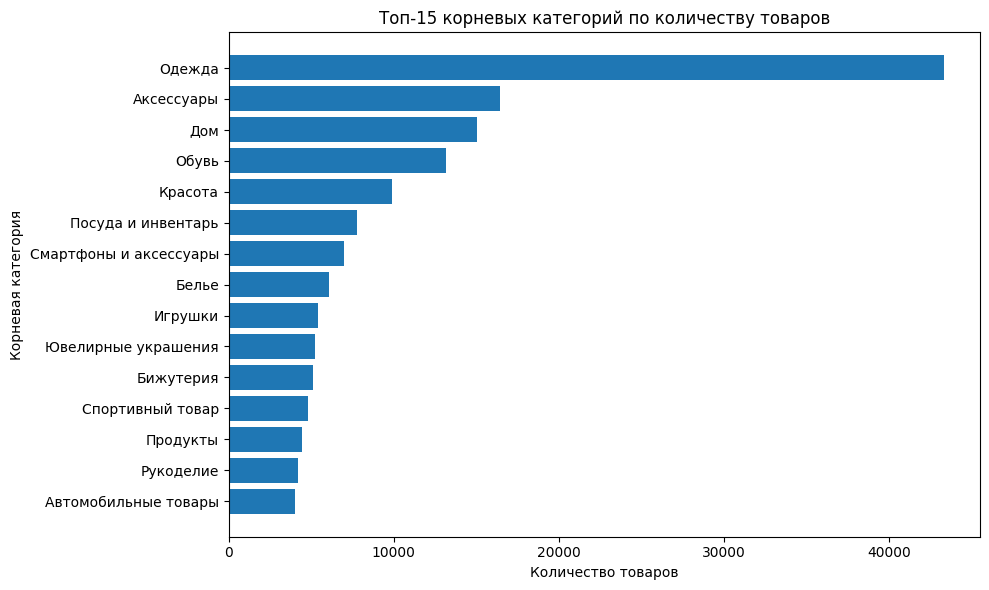

In [10]:
# Распределение товаров по крупнейшим корневым категориям

top_root_categories = root_category_counts.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top_root_categories["Корневая категория"][::-1],
    top_root_categories["Количество товаров"][::-1]
)

plt.title("Топ-15 корневых категорий по количеству товаров")
plt.xlabel("Количество товаров")
plt.ylabel("Корневая категория")
plt.tight_layout()

plt.show()

In [11]:
# Предметные категории внутри кандидатов для MVP

candidate_categories = ["Одежда", "Обувь"]

for root_category in candidate_categories:
    category_data = (
        df_raw.loc[df_raw["subj_root_name"] == root_category, "subj_name"]
        .value_counts()
        .head(15)
        .rename_axis("Предметная категория")
        .reset_index(name="Количество товаров")
    )

    print(f"\nТоп предметных категорий: {root_category}")
    display(category_data)


Топ предметных категорий: Одежда


,Предметная категория,Количество товаров
0,Платья,6998
1,Футболки,5465
2,Брюки,3427
3,Блузки,2342
4,Костюмы,2317
5,Джинсы,1746
6,Рубашки,1689
7,Юбки,1647
8,Джемперы,1442
9,Куртки,1391



Топ предметных категорий: Обувь


,Предметная категория,Количество товаров
0,Туфли,2159
1,Кроссовки,1835
2,Ботинки,1502
3,Босоножки,1205
4,Сапоги,906
5,Кеды,831
6,Сандалии,612
7,Полусапожки,460
8,Полуботинки,411
9,Сабо,411


**Вывод по выбору категорий для MVP.**

Для дальнейшей работы выбраны две корневые категории: `Одежда` и `Обувь`.

Категория `Одежда` содержит 43 316 товаров и включает крупные предметные категории с различимыми пользовательскими назначениями: платья, футболки, брюки, блузки, костюмы, джинсы, рубашки, юбки, куртки и другие.

Категория `Обувь` содержит 13 187 товаров и также имеет хорошо интерпретируемую внутреннюю структуру: туфли, кроссовки, ботинки, босоножки, сапоги, кеды, сандалии и другие типы обуви.

Совместное использование этих категорий даёт достаточно большой каталог для экспериментов и при этом ограничивает предметную область близкими по смыслу товарами. Такой выбор позволит содержательно анализировать ошибки поиска: например, отличать ошибку между близкими категориями `кроссовки` и `кеды` от более грубой ошибки между обувью и предметом одежды.

Рабочее подмножество для MVP: `Одежда` + `Обувь`.

In [12]:
# Анализ длины текстовых полей

text_length_df = df_raw[["imt_name", "description"]].copy()

for column in ["imt_name", "description"]:
    text_length_df[f"{column}_chars"] = (
        text_length_df[column]
        .fillna("")
        .astype(str)
        .str.len()
    )

    text_length_df[f"{column}_words"] = (
        text_length_df[column]
        .fillna("")
        .astype(str)
        .str.split()
        .str.len()
    )

length_summary = text_length_df[
    [
        "imt_name_chars",
        "imt_name_words",
        "description_chars",
        "description_words",
    ]
].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
).T

length_summary.round(2)

,count,mean,std,min,50%,75%,90%,95%,99%,max
imt_name_chars,200000.0,32.87,23.96,0.0,31.0,48.0,65.0,80.0,97.0,122.0
imt_name_words,200000.0,4.80,3.64,0.0,4.0,7.0,10.0,12.0,15.0,31.0
description_chars,200000.0,372.37,474.56,0.0,227.0,563.0,934.0,1082.0,2067.0,5000.0
description_words,200000.0,50.39,64.59,0.0,31.0,75.0,125.0,152.0,289.0,754.0


**Промежуточный вывод по длине текстовых полей.**

Названия товаров в целом короткие: медианная длина составляет 31 символ и 4 слова. Для 95% карточек название не превышает 80 символов и 12 слов, а для 99% — 97 символов и 15 слов. Максимальная длина названия составляет 122 символа и 31 слово.

Описания значительно длиннее и более вариативны. Медианная длина по всему каталогу составляет 227 символов и 31 слово, 95-й перцентиль — 1 082 символа и 152 слова, 99-й перцентиль — 2 067 символов и 289 слов. Максимальное описание достигает 5 000 символов и 754 слов.

Поскольку часть описаний представлена пустыми строками, общая статистика по `description` смещена нулевыми значениями. Для корректной оценки длины содержательных описаний необходимо отдельно исследовать только непустые тексты.

,count,mean,std,min,50%,75%,90%,95%,99%,max
description_chars,142491.0,522.55,486.96,1.0,398.0,732.0,989.0,1325.0,2362.1,5000.0
description_words,142491.0,70.72,66.46,1.0,53.0,97.0,135.0,188.0,321.0,754.0


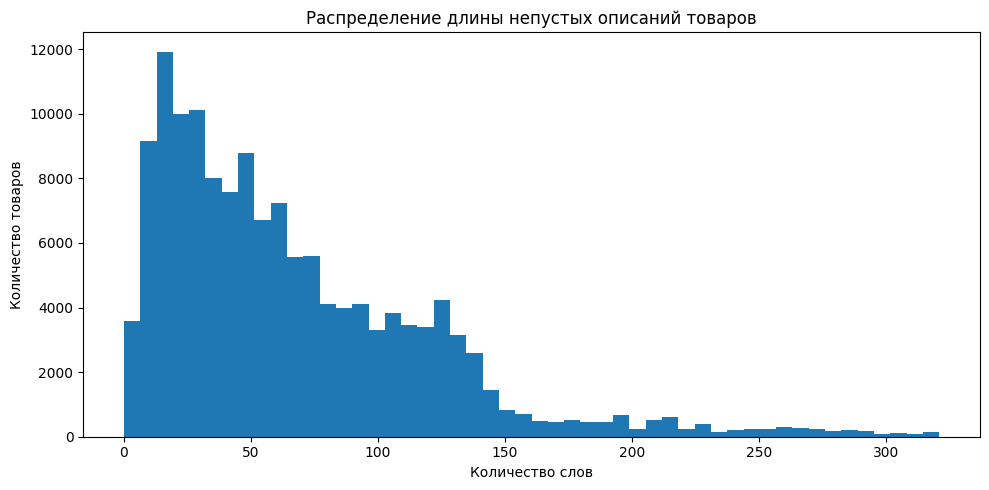

In [13]:
# Анализ длины непустых описаний

non_empty_descriptions = text_length_df[
    text_length_df["description_words"] > 0
].copy()

non_empty_description_summary = (
    non_empty_descriptions[
        ["description_chars", "description_words"]
    ]
    .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
    .T
)

display(non_empty_description_summary.round(2))

# Граница графика — 99-й перцентиль, чтобы редкие выбросы не сжимали основное распределение
description_words_p99 = non_empty_descriptions["description_words"].quantile(0.99)

plt.figure(figsize=(10, 5))
plt.hist(
    non_empty_descriptions["description_words"],
    bins=50,
    range=(0, description_words_p99)
)

plt.title("Распределение длины непустых описаний товаров")
plt.xlabel("Количество слов")
plt.ylabel("Количество товаров")
plt.tight_layout()

plt.show()

**Вывод по длине текстовых полей.**

После исключения пустых значений осталось 142 491 карточка с заполненным `description`, что согласуется с ранее обнаруженной долей пустых описаний 28,75%.

Заполненные описания существенно длиннее названий товаров. Медианная длина описания составляет 398 символов или 53 слова. Для 90% карточек описание не превышает 989 символов и 135 слов, для 95% — 1 325 символов и 188 слов, а для 99% — 2 362 символа и 321 слово.

Максимальная длина достигает 5 000 символов и 754 слов. Распределение имеет выраженный правый хвост: основная масса карточек содержит относительно компактные описания, однако присутствует небольшая группа значительно более длинных текстов.

Это необходимо учитывать при выборе модели эмбеддингов и формировании `product_text`: длинные описания могут превышать доступное контекстное окно конкретной модели и частично обрезаться. Окончательное решение о допустимой длине текста будет приниматься после выбора модели и её лимита токенов.

In [14]:
# Ручной просмотр случайных карточек выбранного домена

mvp_categories = ["Одежда", "Обувь"]

manual_sample = (
    df_raw[df_raw["subj_root_name"].isin(mvp_categories)]
    .sample(n=25, random_state=SEED)
    [
        [
            "imt_id",
            "imt_name",
            "subj_root_name",
            "subj_name",
            "brand_name",
            "nm_colors_names",
            "description",
        ]
    ]
    .copy()
)

manual_sample

,imt_id,imt_name,subj_root_name,subj_name,brand_name,nm_colors_names,description
85717,1007705,Сапоги,Обувь,Сапоги,Vitacci,черный,
73576,10066007,Брюки,Одежда,Брюки,KOTON,черный,
171326,1015934,Платье,Одежда,Платья,Colambetta,"синий, белый",
67663,10060803,Кардиган,Одежда,Кардиганы,Velvet Season,бежевый,"Важная информация! При заказе изделия, обращай..."
87795,10078984,Туфли,Обувь,Туфли,МЫШОНОК,черный,
135770,10127551,Женские брюки,Одежда,Брюки,MODERNFECI,бледно-розовый,
54495,10048604,Рубашка,Одежда,Рубашки,DeFacto,голубой,
193603,10178775,Футболка,Одежда,Футболки,ТВОЕ,темно-серый,
2606,1000231,Пальто,Одежда,Пальто,Kling,"черный, красный, оранжевый",
30453,10027497,Босоножки,Обувь,Босоножки,Buzoni,бежевый,


**Вывод по ручному просмотру карточек.**

Ручной просмотр 25 случайных карточек из выбранных категорий `Одежда` и `Обувь` показывает, что качество и полнота текстового наполнения неоднородны.

Во многих карточках название состоит только из общего типа товара: `Сапоги`, `Брюки`, `Платье`, `Футболка`, `Куртка`. В таких случаях поле `subj_name` дополнительно фиксирует предметную категорию и может быть полезно при формировании текста для поиска.

В части карточек название уже содержит дополнительные характеристики товара, например назначение, сезон или материал. Заполненные описания также содержат полезные сведения, которые отсутствуют в названии: особенности посадки, модели, материала и эксплуатации. Поэтому полностью исключать `description` из поискового текста нецелесообразно.

Поля `brand_name` и `nm_colors_names` заполнены значительно чаще, однако бренд является скорее точным идентификатором товара, а цвет может частично дублировать информацию из названия или описания. Перед включением этих полей в `product_text` необходимо проверить, насколько часто их значения уже присутствуют в других текстовых полях.

По отображённой выборке явные HTML-теги не обнаружены, однако из-за сокращённого отображения длинных описаний этого недостаточно для вывода по всему каталогу. Требуется дополнительная количественная проверка текстового шума.

In [15]:
# Дополнительная проверка текстов в выбранном домене

mvp_df = df_raw[
    df_raw["subj_root_name"].isin(mvp_categories)
].copy()

description_text = (
    mvp_df["description"]
    .fillna("")
    .astype(str)
    .str.strip()
)

non_empty_description_mask = description_text.ne("")

html_mask = description_text.str.contains(
    r"<[^>]+>",
    regex=True,
    na=False
)

url_mask = description_text.str.contains(
    r"https?://|www\.",
    regex=True,
    case=False,
    na=False
)

non_empty_descriptions = description_text[non_empty_description_mask]

duplicate_description_mask = non_empty_descriptions.duplicated(
    keep=False
)


def value_present_in_text(value, text):
    value = str(value).strip().lower()
    text = str(text).lower()

    if not value:
        return False

    return value in text


def color_present_in_text(colors, text):
    colors = str(colors).strip().lower()
    text = str(text).lower()

    if not colors:
        return False

    color_list = [
        color.strip()
        for color in colors.split(",")
        if color.strip()
    ]

    return any(color in text for color in color_list)


combined_text = (
    mvp_df["imt_name"].fillna("").astype(str)
    + " "
    + mvp_df["description"].fillna("").astype(str)
)

brand_already_present = [
    value_present_in_text(brand, text)
    for brand, text in zip(
        mvp_df["brand_name"],
        combined_text
    )
]

color_already_present = [
    color_present_in_text(colors, text)
    for colors, text in zip(
        mvp_df["nm_colors_names"],
        combined_text
    )
]

print(f"Карточек в домене MVP: {len(mvp_df):,}")

print(
    f"\nПустых description: "
    f"{(~non_empty_description_mask).sum():,} "
    f"({(~non_empty_description_mask).mean() * 100:.2f}%)"
)

print(
    f"Описание содержит HTML-теги: "
    f"{html_mask.sum():,} "
    f"({html_mask.mean() * 100:.2f}%)"
)

print(
    f"Описание содержит URL: "
    f"{url_mask.sum():,} "
    f"({url_mask.mean() * 100:.2f}%)"
)

print(
    f"Непустых описаний: "
    f"{len(non_empty_descriptions):,}"
)

print(
    f"Строк с повторяющимися непустыми описаниями: "
    f"{duplicate_description_mask.sum():,} "
    f"({duplicate_description_mask.mean() * 100:.2f}%)"
)

print(
    f"\nБренд уже встречается в названии или описании: "
    f"{sum(brand_already_present):,} "
    f"({np.mean(brand_already_present) * 100:.2f}%)"
)

print(
    f"Цвет уже встречается в названии или описании: "
    f"{sum(color_already_present):,} "
    f"({np.mean(color_already_present) * 100:.2f}%)"
)

Карточек в домене MVP: 56,503

Пустых description: 34,075 (60.31%)
Описание содержит HTML-теги: 4 (0.01%)
Описание содержит URL: 0 (0.00%)
Непустых описаний: 22,428
Строк с повторяющимися непустыми описаниями: 12,314 (54.90%)

Бренд уже встречается в названии или описании: 5,768 (10.21%)
Цвет уже встречается в названии или описании: 808 (1.43%)


**Вывод по качеству текстовых данных выбранного домена.**

В рабочем домене `Одежда` + `Обувь` содержится 56 503 строки.

Поле `description` заполнено только у 39,69% строк: 34 075 строк, или 60,31%, не содержат описания. Это означает, что поисковый текст нельзя строить только на `description` — для значительной части каталога основными источниками информации будут название и предметная категория.

Явный технический шум встречается редко: HTML-теги обнаружены только в 0,01% строк, URL не обнаружены. Следовательно, сложная очистка HTML для данного подмножества не является основной задачей, однако базовая очистка текста всё равно необходима.

Бренд уже присутствует в названии или описании только у 10,21% строк, а цвет — у 1,43%. Следовательно, эти поля в основном содержат дополнительную информацию, а не дублируют существующий текст. При этом их полезность именно для семантического поиска требует отдельного решения: бренд является точным идентификатором, а цвет — дополнительным атрибутом товара.

Повторяющиеся описания обнаружены у 54,90% непустых строк. Однако этот показатель рассчитан до дедупликации по `imt_id`, поэтому часть повторов может приходиться на разные артикулы одной карточки. Перед интерпретацией необходимо отдельно проверить повторение описаний между разными `imt_id`.

In [16]:
# Проверка повторяющихся описаний на уровне карточек imt_id

mvp_cards = mvp_df.copy()

mvp_cards["description_clean"] = (
    mvp_cards["description"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# Одна строка на одну карточку
mvp_cards_unique = (
    mvp_cards
    .sort_values("imt_id")
    .drop_duplicates(subset="imt_id")
    .copy()
)

non_empty_cards = mvp_cards_unique[
    mvp_cards_unique["description_clean"].ne("")
].copy()

description_card_counts = (
    non_empty_cards
    .groupby("description_clean")["imt_id"]
    .nunique()
)

repeated_descriptions = description_card_counts[
    description_card_counts > 1
]

repeated_description_values = set(repeated_descriptions.index)

cards_with_repeated_description = non_empty_cards[
    non_empty_cards["description_clean"].isin(repeated_description_values)
]

print(f"Строк в выбранном домене: {len(mvp_df):,}")
print(f"Уникальных карточек imt_id: {mvp_df['imt_id'].nunique():,}")

print(
    f"\nКарточек с непустым description: "
    f"{len(non_empty_cards):,}"
)

print(
    f"Карточек, описание которых повторяется у другого imt_id: "
    f"{len(cards_with_repeated_description):,} "
    f"({len(cards_with_repeated_description) / len(non_empty_cards) * 100:.2f}%)"
)

print(
    f"Уникальных текстов description, используемых более чем одной карточкой: "
    f"{len(repeated_descriptions):,}"
)

print(
    f"Максимальное число разных imt_id с одинаковым description: "
    f"{repeated_descriptions.max() if len(repeated_descriptions) else 1:,}"
)

Строк в выбранном домене: 56,503
Уникальных карточек imt_id: 48,489

Карточек с непустым description: 18,082
Карточек, описание которых повторяется у другого imt_id: 6,474 (35.80%)
Уникальных текстов description, используемых более чем одной карточкой: 1,583
Максимальное число разных imt_id с одинаковым description: 152


**Вывод по повторяющимся описаниям.**

После перехода на уровень уникальных карточек `imt_id` в выбранном домене остаётся 48 489 карточек, из которых 18 082 имеют непустое описание.

У 6 474 карточек, или 35,80% карточек с заполненным `description`, текст описания полностью совпадает с описанием хотя бы одной другой карточки. Всего обнаружено 1 583 повторяющихся текста, а один и тот же `description` в наиболее выраженном случае используется сразу у 152 различных карточек.

Следовательно, высокая доля повторов объясняется не только наличием нескольких артикулов одной карточки. В каталоге действительно присутствуют шаблонные или повторно используемые описания разных товаров.

Поле `description` содержит полезные характеристики товара, однако использовать его как единственный или главный источник текста для поиска нецелесообразно. Более устойчивой основой должны быть `imt_name` и `subj_name`, а описание следует использовать как дополнительный источник информации.

In [17]:
# Просмотр наиболее часто повторяющихся описаний

top_repeated_descriptions = (
    description_card_counts
    .sort_values(ascending=False)
    .head(10)
)

for i, (description, card_count) in enumerate(
    top_repeated_descriptions.items(),
    start=1
):
    print(f"\n{i}. Количество карточек: {card_count}")
    print(description[:700])
    print("-" * 100)


1. Количество карточек: 152
Не спешите писать негативный отзыв при следующих ситуациях, независящих от нас: 1. Доставка задержалась или качество обслуживания в пункте выдачи не оправдало Ваших ожиданий. В данном случае напишите в техподдержку для оперативного решения. 2. Товар пришел поврежденным. Вы вправе отказаться от покупки и/или оформить возврат по браку. Товар спишут и утилизируют за наши средства, несмотря на вину доставщика/курьера, а Вам вернут денежные средства. 3. Пришел абсолютно другой товар. Пересортица товаров может происходить на складе. К сожалению, мы никак не можем повлиять на работу отдельных сотрудников марткеплейса, как бы этого не хотели. В данном случае необходимо оформить возврат, написать в т
----------------------------------------------------------------------------------------------------

2. Количество карточек: 113
Легкая и практичная Российская одежда бренда "Линум" как правило из льна и шерсти, плотная, качественная ткань, выпущенная ограниченной парт

**Вывод по содержанию повторяющихся описаний.**

Ручной просмотр наиболее часто повторяющихся `description` подтверждает наличие шаблонного и нерелевантного для конкретного товара текста.

Среди повторяющихся описаний встречаются:

- сообщения о доставке, возвратах и работе маркетплейса;
- общие рекламные описания бренда;
- одинаковые гарантийные формулировки;
- предложения найти другие товары бренда;
- общие описания товарной линейки, используемые сразу для большого числа карточек.

Следовательно, `description` содержит полезные характеристики товара, но одновременно является источником заметного текстового шума. Использовать его как основное текстовое поле для поиска рискованно: одинаковые шаблонные фрагменты могут искусственно сближать разные товары.

Для базового варианта `product_text` наиболее устойчивыми признаками являются название товара `imt_name` и предметная категория `subj_name`. Поле `description` целесообразно сохранить как дополнительный источник информации и отдельно проверить его влияние на качество поиска в дальнейших экспериментах.

**Варианты формирования `product_text`.**

По результатам EDA сформированы три осмысленных варианта текста товара:

1. `imt_name`  
   Минимальный вариант, содержащий только название товара. Обладает наименьшим количеством шума, но для коротких названий вроде «Сапоги» или «Футболка» содержит слишком мало информации.

2. `imt_name + subj_name`  
   Название дополняется явной предметной категорией. Этот вариант сохраняет компактность текста и помогает точнее определить тип товара даже при малоинформативном названии.

3. `imt_name + subj_name + description`  
   В текст добавляется подробное описание товара. Это может помочь при запросах по назначению, материалу или особенностям использования, однако `description` содержит много пустых значений и заметную долю повторяющихся шаблонных текстов.

**Базовый шаблон для следующего этапа:** `imt_name + subj_name`.

Вариант с добавлением `description` будет рассматриваться как отдельная гипотеза для сравнения качества поиска.

In [18]:
# Дополнительная статистика категорий и атрибутов

# Самые редкие предметные категории
rare_subject_categories = (
    df_raw["subj_name"]
    .value_counts()
    .sort_values()
    .head(20)
    .rename_axis("Предметная категория")
    .reset_index(name="Количество товаров")
)

print("20 самых редких предметных категорий:")
display(rare_subject_categories)

# Количество уникальных брендов
non_empty_brands = (
    df_raw["brand_name"]
    .fillna("")
    .astype(str)
    .str.strip()
)

unique_brands = non_empty_brands[non_empty_brands.ne("")].nunique()

print(f"\nУникальных непустых брендов: {unique_brands:,}")

# Проверка: встречается ли цвет уже в названии товара
def color_present_in_name(colors, name):
    colors = str(colors).strip().lower()
    name = str(name).lower()

    if not colors:
        return False

    color_list = [
        color.strip()
        for color in colors.split(",")
        if color.strip()
    ]

    return any(color in name for color in color_list)


color_in_name = [
    color_present_in_name(colors, name)
    for colors, name in zip(
        df_raw["nm_colors_names"],
        df_raw["imt_name"]
    )
]

non_empty_colors = (
    df_raw["nm_colors_names"]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
)

color_in_name_count = sum(
    present
    for present, has_color
    in zip(color_in_name, non_empty_colors)
    if has_color
)

print(
    f"Строк с заполненным цветом: "
    f"{non_empty_colors.sum():,}"
)

print(
    f"Цвет встречается в названии: "
    f"{color_in_name_count:,} "
    f"({color_in_name_count / non_empty_colors.sum() * 100:.2f}%)"
)

20 самых редких предметных категорий:


,Предметная категория,Количество товаров
0,Аппараты для сварки труб,1
1,Шторки для колясок и кресел,1
2,Колеса мебельные,1
3,Распарыватели,1
4,Портсигары,1
5,Пасты для животных,1
6,Шилья,1
7,Кронштейны для велосипедов,1
8,Петли-вешалки,1
9,Компрессионные гетры,1



Уникальных непустых брендов: 13,318
Строк с заполненным цветом: 165,774
Цвет встречается в названии: 4,406 (2.66%)


**Вывод по редким категориям и атрибутам.**

В каталоге присутствует большое количество крайне редких предметных категорий: среди самых редких обнаружены категории, представленные всего одной карточкой. Это подтверждает высокую разреженность полного каталога и дополнительно обосновывает использование ограниченного предметного домена `Одежда` + `Обувь` для MVP.

Количество уникальных непустых брендов составляет 13 318, то есть признак `brand_name` имеет очень высокую кардинальность.

Цвет заполнен у 165 774 строк, однако непосредственно в названии товара он встречается только у 4 406 строк, или 2,66% строк с указанным цветом. Следовательно, `nm_colors_names` в большинстве случаев содержит дополнительную информацию, отсутствующую в `imt_name`.

На базовом этапе бренд и цвет не включаются в основной шаблон `product_text`. Их целесообразно сохранить как отдельные атрибуты и при необходимости проверить в дальнейших экспериментах или использовать для фильтрации результатов поиска.

In [19]:
# Статистика train-разметки

items_per_query = (
    queries_train
    .groupby("query_id")["item_id"]
    .nunique()
)

relevance_distribution = (
    queries_train["relevance"]
    .value_counts()
    .sort_index()
    .rename_axis("relevance")
    .reset_index(name="Количество")
)

relevance_distribution["Доля, %"] = (
    relevance_distribution["Количество"]
    / len(queries_train)
    * 100
)

queries_with_relevant = (
    queries_train
    .assign(is_relevant=queries_train["relevance"] >= 2)
    .groupby("query_id")["is_relevant"]
    .any()
)

print(f"Всего пар запрос — товар: {len(queries_train):,}")
print(f"Уникальных query_id: {queries_train['query_id'].nunique():,}")

print("\nКоличество оценённых товаров на запрос:")
display(
    items_per_query
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    .to_frame("Количество товаров")
    .round(2)
)

print("\nРаспределение relevance:")
display(relevance_distribution.round(2))

print(
    f"\nЗапросов, у которых есть хотя бы один товар с relevance >= 2: "
    f"{queries_with_relevant.sum():,} "
    f"из {len(queries_with_relevant):,} "
    f"({queries_with_relevant.mean() * 100:.2f}%)"
)

print(
    f"Запросов без товаров с relevance >= 2: "
    f"{(~queries_with_relevant).sum():,}"
)

Всего пар запрос — товар: 11,453
Уникальных query_id: 700

Количество оценённых товаров на запрос:


,Количество товаров
count,700.00
mean,16.36
std,5.42
min,1.00
25%,14.00
50%,16.00
75%,19.00
90%,23.00
95%,26.00
99%,30.00



Распределение relevance:


,relevance,Количество,"Доля, %"
0,1,9652,84.27
1,2,1101,9.61
2,3,700,6.11



Запросов, у которых есть хотя бы один товар с relevance >= 2: 700 из 700 (100.00%)
Запросов без товаров с relevance >= 2: 0


**Вывод по структуре train-разметки.**

Train-разметка содержит 11 453 пары «запрос — товар» для 700 уникальных запросов.

В среднем на один запрос приходится 16,36 оценённого товара, медиана составляет 16. Минимальное количество оценённых товаров для одного запроса — 1, максимальное — 31. Для 95% запросов размечено не более 26 товаров.

Распределение оценок существенно несбалансировано: 84,27% пар имеют `relevance = 1`, 9,61% — `relevance = 2`, и 6,11% — `relevance = 3`. Значение `relevance = 0` в train-разметке отсутствует, несмотря на заявленную шкалу от 0 до 3. Это необходимо учитывать при последующей интерпретации метрик и состава оценочного пула.

При этом у всех 700 запросов имеется хотя бы один товар с `relevance >= 2`. Следовательно, каждый запрос содержит хотя бы один релевантный объект, пригодный для оценки качества ранжирования.

In [20]:
# Анализ текстов поисковых запросов

unique_queries = (
    queries_train[
        ["query_id", "query_text"]
    ]
    .drop_duplicates()
    .copy()
)

unique_queries["query_chars"] = (
    unique_queries["query_text"]
    .fillna("")
    .astype(str)
    .str.len()
)

unique_queries["query_words"] = (
    unique_queries["query_text"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

print("Статистика длины query_text:")

display(
    unique_queries[
        ["query_chars", "query_words"]
    ]
    .describe(
        percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
    )
    .T
    .round(2)
)

print("\n20 случайных уникальных запросов:")

display(
    unique_queries[
        ["query_id", "query_text"]
    ]
    .sample(
        n=20,
        random_state=SEED
    )
    .sort_values("query_id")
)

Статистика длины query_text:


,count,mean,std,min,50%,75%,90%,95%,99%,max
query_chars,700.0,19.44,6.5,8.0,18.0,23.0,29.0,32.0,39.0,50.0
query_words,700.0,2.70,0.9,2.0,2.0,3.0,4.0,4.0,6.0,7.0



20 случайных уникальных запросов:


,query_id,query_text
1209,SYN_000107,прямые жакеты
2446,SYN_000206,кожаные мокасины
2484,SYN_000210,топы cop copine
3139,SYN_000264,мужские резиновые сапоги
3373,SYN_000286,классические джинсовые джинсы
3746,SYN_000318,шубы натуральные на пуговицах
4678,SYN_000401,тапочки asd
4852,SYN_000414,тапочки t taccardi
5214,SYN_000450,кожаные сабо с открытым мысом
5322,SYN_000460,дышащий дутики


**Вывод по природе поисковых запросов.**

Поисковые запросы являются короткими текстовыми фразами. Средняя длина составляет 19,44 символа и 2,70 слова, медианная — 18 символов и 2 слова. Даже самые длинные запросы остаются компактными: максимум составляет 50 символов и 7 слов.

В выборке встречаются запросы вида `кожаные мокасины`, `мужские резиновые сапоги`, `белые классические кеды`, `футболки поло на пуговицах`. Пользователь обычно указывает тип товара и один или несколько дополнительных признаков: материал, цвет, фасон, назначение или бренд.

Запросы не являются полными текстами товарных карточек и не копируют длинные описания товаров. Следовательно, задача соответствует постановке `query-to-item`: по короткому поисковому запросу необходимо найти наиболее релевантные карточки товаров.

При этом часть формулировок имеет искусственный характер, что следует учитывать при интерпретации итоговых результатов на синтетической разметке.

---

## Неделя 2 — базовый пайплайн и оценка качества

**Цель:** оперевшись на результаты EDA, создать работающий поиск и получить первые метрики качества.

Прежде чем реализовывать семантический поиск, основанный на эмбеддингах, нужно проверить, как справляется более простая модель, опирающаяся на TF-IDF. Простая модель нужна как baseline, без этой точки отсчёта результат невозможно интерпретировать.


### 1. Подготовка данных


Реализуйте решения недели 1:

1. Отфильтруйте выбранные категории.
2. Дедуплицируйте строки по `imt_id`. Сформулируйте правило, по которому будете определять, какую строку оставить. К примеру, можете оставить строку с самым информативным описанием. Ответ обоснуйте.
3. Отбросьте карточки, у которых пусты одновременно и `imt_name`, и `description`.
4. Напишите функцию очистки текста.
5. Соберите единый текст карточек в отдельной колонке `product_text`.

In [21]:
# Ваш код: фильтрация, дедупликация, отсев пустых, очистка, сборка product_text

# Проверка покрытия train-разметки выбранными категориями

SELECTED_CATEGORIES = ["Одежда", "Обувь"]

train_item_ids = set(queries_train["item_id"].unique())

train_products = (
    df_raw.loc[
        df_raw["imt_id"].isin(train_item_ids),
        ["imt_id", "subj_root_name"]
    ]
    .drop_duplicates()
)

category_coverage = (
    train_products["subj_root_name"]
    .value_counts()
    .rename_axis("Корневая категория")
    .reset_index(name="Количество размеченных карточек")
)

covered_train_ids = set(
    train_products.loc[
        train_products["subj_root_name"].isin(SELECTED_CATEGORIES),
        "imt_id"
    ]
)

missing_train_ids = train_item_ids - covered_train_ids

print(f"Уникальных размеченных item_id в train: {len(train_item_ids):,}")
print(f"Покрыто категориями Одежда + Обувь: {len(covered_train_ids):,}")
print(f"Не покрыто выбранными категориями: {len(missing_train_ids):,}")
print(f"Доля покрытия: {len(covered_train_ids) / len(train_item_ids):.2%}")

print("\nРаспределение размеченных товаров по корневым категориям:")
display(category_coverage)

assert len(missing_train_ids) == 0, (
    f"Выбранные категории не покрывают "
    f"{len(missing_train_ids)} размеченных item_id из train"
)

Уникальных размеченных item_id в train: 2,285
Покрыто категориями Одежда + Обувь: 2,285
Не покрыто выбранными категориями: 0
Доля покрытия: 100.00%

Распределение размеченных товаров по корневым категориям:


,Корневая категория,Количество размеченных карточек
0,Одежда,1689
1,Обувь,596


In [22]:
# Подготовка каталога для поиска

# Фильтрация выбранных категорий
catalog = df_raw[
    df_raw["subj_root_name"].isin(SELECTED_CATEGORIES)
].copy()

rows_after_filter = len(catalog)

# Длина описания для выбора наиболее информативного артикула
catalog["_description_len"] = (
    catalog["description"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.len()
)

# Дедупликация по imt_id:
# для каждой карточки сохраняется строка с самым длинным description
catalog = (
    catalog
    .sort_values(
        ["imt_id", "_description_len"],
        ascending=[True, False],
        kind="mergesort"
    )
    .drop_duplicates(subset="imt_id", keep="first")
    .copy()
)

rows_after_dedup = len(catalog)

# Определение карточек без текстовой информации
empty_name = (
    catalog["imt_name"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
)

empty_description = (
    catalog["description"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
)

no_text_mask = empty_name & empty_description
removed_without_text = int(no_text_mask.sum())

catalog = catalog.loc[~no_text_mask].copy()

# Очистка текстовых полей
def clean_text(text):
    text = "" if pd.isna(text) else str(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^\w\s-]", " ", text, flags=re.UNICODE)
    text = re.sub(r"\s+", " ", text)
    return text.strip().lower()


catalog["imt_name_clean"] = catalog["imt_name"].apply(clean_text)
catalog["subj_name_clean"] = catalog["subj_name"].apply(clean_text)
catalog["description_clean"] = catalog["description"].apply(clean_text)

# Базовый шаблон product_text, выбранный по результатам EDA
catalog["product_text"] = (
    catalog["imt_name_clean"] + " " + catalog["subj_name_clean"]
).str.replace(r"\s+", " ", regex=True).str.strip()

# Удаление служебной колонки
catalog = catalog.drop(columns="_description_len")

print(f"Строк после фильтрации категорий: {rows_after_filter:,}")
print(f"Уникальных карточек после дедупликации: {rows_after_dedup:,}")
print(f"Удалено карточек без imt_name и description: {removed_without_text:,}")
print(f"Итоговый размер каталога: {len(catalog):,}")
print(f"Уникальных imt_id в каталоге: {catalog['imt_id'].nunique():,}")
print(f"Пустых product_text: {(catalog['product_text'] == '').sum():,}")

print("\nПример подготовленного каталога:")
display(
    catalog[
        [
            "imt_id",
            "imt_name",
            "subj_name",
            "description",
            "product_text"
        ]
    ].head(10)
)

Строк после фильтрации категорий: 56,503
Уникальных карточек после дедупликации: 48,489
Удалено карточек без imt_name и description: 113
Итоговый размер каталога: 48,376
Уникальных imt_id в каталоге: 48,376
Пустых product_text: 0

Пример подготовленного каталога:


,imt_id,imt_name,subj_name,description,product_text
3737,100032,Платье,Платья,,платье платья
3866,100033,Куртка,Куртки,,куртка куртки
4113,100035,Сандалии,Сандалии,,сандалии сандалии
4333,100037,Ботинки,Ботинки,,ботинки ботинки
9231,100083,Сандалии,Сандалии,,сандалии сандалии
9326,100084,Туфли,Туфли,,туфли туфли
9433,100085,Ботинки,Ботинки,,ботинки ботинки
9565,100087,Ботинки,Ботинки,,ботинки ботинки
9757,100089,Ветровка,Ветровки,,ветровка ветровки
9878,100090,Брюки,Брюки,,брюки брюки


**Вывод по подготовке каталога.**

После фильтрации категорий `Одежда` и `Обувь` в рабочем подмножестве осталось 56 503 строки.

Дедупликация по `imt_id` сократила каталог до 48 489 уникальных карточек. Для карточек с несколькими артикулами сохранялась строка с наиболее длинным `description`, чтобы использовать максимально информативное представление товара.

Дополнительно удалено 113 карточек, у которых одновременно отсутствовали `imt_name` и `description`. Итоговый каталог содержит 48 376 уникальных карточек.

Для всех оставшихся товаров успешно сформирован `product_text`; пустых значений нет. В качестве базового шаблона используется `imt_name + subj_name`, выбранный по результатам EDA как наиболее компактный и устойчивый к шуму вариант.

In [23]:
# Проверка сохранности всех размеченных товаров после подготовки каталога

catalog_item_ids = set(catalog["imt_id"])
missing_train_after_prepare = train_item_ids - catalog_item_ids

print(f"Размеченных item_id в train: {len(train_item_ids):,}")
print(f"Найдено в подготовленном каталоге: {len(train_item_ids & catalog_item_ids):,}")
print(f"Отсутствует после подготовки: {len(missing_train_after_prepare):,}")

assert len(missing_train_after_prepare) == 0, (
    f"После подготовки каталога потеряно "
    f"{len(missing_train_after_prepare)} размеченных item_id"
)

Размеченных item_id в train: 2,285
Найдено в подготовленном каталоге: 2,285
Отсутствует после подготовки: 0


**Проверка сохранности разметки.**

После фильтрации, дедупликации и удаления карточек без текстовой информации все 2 285 уникальных `item_id` из train-разметки сохранились в подготовленном каталоге.

Следовательно, этап подготовки данных не привёл к потере размеченных товаров, и каталог можно использовать для построения поисковых индексов и дальнейшей оценки качества.

### Каталог для поиска и оценки

1. Посчитайте метрику при поиске по всему отфильтрованному каталогу. Например, вычислите NDCG@10 лексическим поиском на 100 запросах.
2. Выведите топ-10 для одного запроса и отметьте, какие товары есть в разметке, а каких нет. Выясните, в чём проблема.
3. Ограничьте каталог оценки пулом асессоров: возьмите из `wb_products_dedup.parquet` только список `imt_id` и оставьте в своём подготовленном каталоге пересечение с ним. Тексты и все признаки — ваши, из шага 1.
4. Пересчитайте метрику и сравните результаты.
5. Посмотрите на распределение `relevance` и число оценённых товаров на запрос. Проверьте, у всех ли запросов есть товары с `relevance` ≥ 2.

In [24]:
# Подготовка каталога для оценки по пулу асессоров

assessed_pool = pd.read_parquet(ASSESSED_POOL_PATH)

assessed_item_ids = set(
    assessed_pool["imt_id"].dropna().unique()
)

catalog_eval = (
    catalog[catalog["imt_id"].isin(assessed_item_ids)]
    .copy()
    .reset_index(drop=True)
)

catalog_eval_item_ids = set(catalog_eval["imt_id"])

missing_train_in_eval = train_item_ids - catalog_eval_item_ids

print(f"Уникальных imt_id в пуле асессоров: {len(assessed_item_ids):,}")
print(f"Карточек из пула асессоров в подготовленном каталоге: {len(catalog_eval):,}")
print(f"Уникальных imt_id в каталоге оценки: {catalog_eval['imt_id'].nunique():,}")
print(f"Размеченных train item_id вне каталога оценки: {len(missing_train_in_eval):,}")

assert catalog_eval["imt_id"].is_unique, (
    "В каталоге оценки обнаружены дубли imt_id"
)

assert len(missing_train_in_eval) == 0, (
    f"Каталог оценки не содержит "
    f"{len(missing_train_in_eval)} размеченных item_id из train"
)

Уникальных imt_id в пуле асессоров: 4,256
Карточек из пула асессоров в подготовленном каталоге: 4,256
Уникальных imt_id в каталоге оценки: 4,256
Размеченных train item_id вне каталога оценки: 0


**Вывод по каталогу оценки.**

Пул асессоров содержит 4 256 уникальных карточек `imt_id`. Все они присутствуют в подготовленном каталоге после фильтрации, дедупликации и очистки.

Все 2 285 размеченных `item_id` из train-разметки также входят в каталог оценки. Следовательно, `catalog_eval` может использоваться как единое множество кандидатов для сопоставимого расчёта метрик лексического и семантического поиска.

Распределение `relevance` и число оценённых товаров на запрос были исследованы на этапе EDA. Train-разметка содержит 700 запросов, и для каждого из них имеется хотя бы один товар с `relevance >= 2`, поэтому все запросы пригодны для расчёта метрик ранжирования.

### 2. Модели поиска

Реализуйте два поисковых движка с одинаковым интерфейсом. Это позволит прогнать оба через одну функцию оценки:


Реализуйте лексический baseline на TF-IDF:

In [25]:
# TF-IDF-индекс и лексический поиск

# Полный подготовленный каталог используется для диагностического сравнения,
# каталог оценочного пула — для основной оценки качества
catalog_search = catalog.reset_index(drop=True)

tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50_000,
    sublinear_tf=True,
    norm="l2",
    dtype=np.float32,
)

# Обучение TF-IDF на полном поисковом каталоге
tfidf_matrix_full = tfidf_vectorizer.fit_transform(
    catalog_search["product_text"]
)

# Представление каталога оценочного пула в том же пространстве признаков
tfidf_matrix_eval = tfidf_vectorizer.transform(
    catalog_eval["product_text"]
)


def _search_lexical(
    query: str,
    search_catalog: pd.DataFrame,
    search_matrix,
    top_k: int = 10
) -> pd.DataFrame:
    """Выполняет TF-IDF-поиск по переданному каталогу."""

    query_clean = clean_text(query)
    query_vector = tfidf_vectorizer.transform([query_clean])

    scores = (search_matrix @ query_vector.T).toarray().ravel()

    top_k = min(top_k, len(search_catalog))

    if query_vector.nnz == 0:
        top_indices = np.arange(top_k)
    else:
        top_indices = np.argsort(scores)[::-1][:top_k]

    result = search_catalog.iloc[top_indices][
        ["imt_id", "imt_name", "subj_name", "product_text"]
    ].copy()

    result["score"] = scores[top_indices]

    return result.reset_index(drop=True)


def search_lexical(query: str, top_k: int = 10) -> pd.DataFrame:
    """Возвращает top_k товаров из каталога оценки."""

    return _search_lexical(
        query=query,
        search_catalog=catalog_eval,
        search_matrix=tfidf_matrix_eval,
        top_k=top_k,
    )


def search_lexical_full(query: str, top_k: int = 10) -> pd.DataFrame:
    """Возвращает top_k товаров из полного подготовленного каталога."""

    return _search_lexical(
        query=query,
        search_catalog=catalog_search,
        search_matrix=tfidf_matrix_full,
        top_k=top_k,
    )


print(f"Размер словаря TF-IDF: {len(tfidf_vectorizer.vocabulary_):,}")
print(f"Матрица полного каталога: {tfidf_matrix_full.shape}")
print(f"Матрица каталога оценки: {tfidf_matrix_eval.shape}")

display(
    search_lexical(
        "белые классические кеды",
        top_k=10
    )
)

Размер словаря TF-IDF: 28,132
Матрица полного каталога: (48376, 28132)
Матрица каталога оценки: (4256, 28132)


,imt_id,imt_name,subj_name,product_text,score
0,10084411,Кеды,Кеды,кеды кеды,0.222981
1,10085231,Кеды,Кеды,кеды кеды,0.222981
2,10029552,Кеды,Кеды,кеды кеды,0.222981
3,10029549,Кеды,Кеды,кеды кеды,0.222981
4,10076964,Кеды,Кеды,кеды кеды,0.222981
5,10029538,Кеды,Кеды,кеды кеды,0.222981
6,10075179,Кеды,Кеды,кеды кеды,0.222981
7,1004913,Кеды,Кеды,кеды кеды,0.222981
8,10165377,Кеды,Кеды,кеды кеды,0.222981
9,10099915,Кеды,Кеды,кеды кеды,0.222981


**Промежуточный вывод по лексическому baseline.**

TF-IDF-индекс построен по полному подготовленному каталогу из 48 376 карточек. Размер словаря составил 28 132 признака. Для основной оценки дополнительно сформировано представление пула асессоров из 4 256 карточек в том же пространстве признаков.

На демонстрационном запросе `белые классические кеды` лексический поиск корректно выделяет категорию `Кеды`, однако дополнительные признаки запроса — `белые` и `классические` — не влияют на ранжирование, поскольку отсутствуют в базовом `product_text = imt_name + subj_name`.

В результате несколько карточек с одинаковым текстом `кеды кеды` получают одинаковое значение сходства. Это является ожидаемым ограничением базового шаблона текста и лексического подхода и будет учитываться при последующем сравнении с семантическим поиском.

Реализуйте семантический поиск:

In [26]:
# Эмбеддинги и семантический поиск

SEMANTIC_MODEL_NAME = (
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

SEMANTIC_EMBEDDINGS_PATH = (
    "semantic_embeddings_paraphrase_multilingual_minilm_l12_v2.npy"
)

device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Устройство: {device}")
print(f"Модель: {SEMANTIC_MODEL_NAME}")

semantic_model = SentenceTransformer(
    SEMANTIC_MODEL_NAME,
    device=device,
)

# Эмбеддинги считаются один раз для полного подготовленного каталога
if os.path.exists(SEMANTIC_EMBEDDINGS_PATH):
    semantic_embeddings_full = np.load(
        SEMANTIC_EMBEDDINGS_PATH
    )

    if semantic_embeddings_full.shape[0] != len(catalog_search):
        raise ValueError(
            "Сохранённые эмбеддинги не соответствуют текущему каталогу"
        )

    print("Эмбеддинги загружены с диска.")

else:
    semantic_embeddings_full = semantic_model.encode(
        catalog_search["product_text"].tolist(),
        batch_size=128 if device == "cuda" else 64,
        show_progress_bar=True,
        normalize_embeddings=True,
        convert_to_numpy=True,
    ).astype(np.float32)

    np.save(
        SEMANTIC_EMBEDDINGS_PATH,
        semantic_embeddings_full,
    )

    print("Эмбеддинги рассчитаны и сохранены.")

# Получение строк оценочного каталога из полного каталога
full_index_by_imt_id = pd.Series(
    catalog_search.index,
    index=catalog_search["imt_id"],
)

eval_indices = catalog_eval["imt_id"].map(
    full_index_by_imt_id
)

assert eval_indices.notna().all(), (
    "Не все товары каталога оценки найдены в полном каталоге"
)

semantic_embeddings_eval = semantic_embeddings_full[
    eval_indices.astype(int).to_numpy()
]


def _search_semantic(
    query: str,
    search_catalog: pd.DataFrame,
    search_embeddings: np.ndarray,
    top_k: int = 10
) -> pd.DataFrame:
    """Выполняет семантический поиск по переданному каталогу."""

    query_clean = clean_text(query)

    query_embedding = semantic_model.encode(
        [query_clean],
        normalize_embeddings=True,
        convert_to_numpy=True,
        show_progress_bar=False,
    )[0]

    scores = search_embeddings @ query_embedding

    top_k = min(top_k, len(search_catalog))

    top_indices = np.argpartition(
        scores,
        -top_k
    )[-top_k:]

    top_indices = top_indices[
        np.argsort(scores[top_indices])[::-1]
    ]

    result = search_catalog.iloc[top_indices][
        ["imt_id", "imt_name", "subj_name", "product_text"]
    ].copy()

    result["score"] = scores[top_indices]

    return result.reset_index(drop=True)


def search_semantic(
    query: str,
    top_k: int = 10
) -> pd.DataFrame:
    """Возвращает top_k товаров из каталога оценки."""

    return _search_semantic(
        query=query,
        search_catalog=catalog_eval,
        search_embeddings=semantic_embeddings_eval,
        top_k=top_k,
    )


def search_semantic_full(
    query: str,
    top_k: int = 10
) -> pd.DataFrame:
    """Возвращает top_k товаров из полного подготовленного каталога."""

    return _search_semantic(
        query=query,
        search_catalog=catalog_search,
        search_embeddings=semantic_embeddings_full,
        top_k=top_k,
    )


print(
    f"Матрица эмбеддингов полного каталога: "
    f"{semantic_embeddings_full.shape}"
)

print(
    f"Матрица эмбеддингов каталога оценки: "
    f"{semantic_embeddings_eval.shape}"
)

display(
    search_semantic(
        "белые классические кеды",
        top_k=10,
    )
)

Устройство: cpu
Модель: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/756 [00:00<?, ?it/s]

Эмбеддинги рассчитаны и сохранены.
Матрица эмбеддингов полного каталога: (48376, 384)
Матрица эмбеддингов каталога оценки: (4256, 384)


,imt_id,imt_name,subj_name,product_text,score
0,10047492,Кеды нубук с белой подошвой,Кеды,кеды нубук с белой подошвой кеды,0.866487
1,101550635,Легкие кеды на шнуровке,Кеды,легкие кеды на шнуровке кеды,0.772412
2,10111004,Кеды женские белые летние с перфорацией низкие,Кеды,кеды женские белые летние с перфорацией низкие...,0.771072
3,10178431,Кеды белые детские натуральная кожа,Кеды,кеды белые детские натуральная кожа кеды,0.747784
4,10075172,Кеды Reflex высокие классика,Кеды,кеды reflex высокие классика кеды,0.746665
5,10075174,Кеды Reflex высокие классика,Кеды,кеды reflex высокие классика кеды,0.746665
6,10075181,Кеды Reflex высокие классика,Кеды,кеды reflex высокие классика кеды,0.746665
7,10174721,Кеды NIKE COURT VINTAGE,Кеды,кеды nike court vintage кеды,0.735932
8,10106809,Кеды Carina slim SD,Кеды,кеды carina slim sd кеды,0.726076
9,10106803,Кеды Caracal V PS,Кеды,кеды caracal v ps кеды,0.705197


**Промежуточный вывод по семантическому baseline.**

Для семантического поиска использована открытая мультиязычная модель `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`.

Для полного каталога рассчитано 48 376 нормализованных эмбеддингов размерности 384, для каталога оценки — 4 256 эмбеддингов.

На запросе `белые классические кеды` семантический поиск, в отличие от лексического baseline, учитывает дополнительные смысловые признаки запроса. В верхней части выдачи появились карточки с упоминаниями белого цвета и классического фасона, в том числе при несовпадении точной словоформы.

Это предварительно показывает способность embedding-модели учитывать семантическое сходство, однако количественный вывод о качестве будет сделан только после расчёта единых метрик.

Прогоните 3–5 запросов вручную и сравните выдачу обоих подходов. Это самый простой способ поймать грубые ошибки до подсчёта метрик.

In [27]:
# Ручное сравнение лексического и семантического поиска

manual_queries = [
    "белые классические кеды",
    "кожаные мокасины",
    "мужские резиновые сапоги",
    "футболки поло на пуговицах",
    "прямые жакеты",
]

for query in manual_queries:
    print(f"\nЗапрос: {query}")
    print("-" * 100)

    lexical_result = search_lexical(
        query,
        top_k=5,
    ).copy()

    lexical_result.insert(
        0,
        "model",
        "TF-IDF",
    )

    lexical_result.insert(
        1,
        "rank",
        range(1, len(lexical_result) + 1),
    )

    semantic_result = search_semantic(
        query,
        top_k=5,
    ).copy()

    semantic_result.insert(
        0,
        "model",
        "Semantic",
    )

    semantic_result.insert(
        1,
        "rank",
        range(1, len(semantic_result) + 1),
    )

    comparison = pd.concat(
        [
            lexical_result[
                ["model", "rank", "imt_id", "imt_name", "subj_name", "score"]
            ],
            semantic_result[
                ["model", "rank", "imt_id", "imt_name", "subj_name", "score"]
            ],
        ],
        ignore_index=True,
    )

    display(comparison)


Запрос: белые классические кеды
----------------------------------------------------------------------------------------------------


,model,rank,imt_id,imt_name,subj_name,score
0,TF-IDF,1,10084411,Кеды,Кеды,0.222981
1,TF-IDF,2,10085231,Кеды,Кеды,0.222981
2,TF-IDF,3,10029552,Кеды,Кеды,0.222981
3,TF-IDF,4,10029549,Кеды,Кеды,0.222981
4,TF-IDF,5,10076964,Кеды,Кеды,0.222981
5,Semantic,1,10047492,Кеды нубук с белой подошвой,Кеды,0.866487
6,Semantic,2,101550635,Легкие кеды на шнуровке,Кеды,0.772412
7,Semantic,3,10111004,Кеды женские белые летние с перфорацией низкие,Кеды,0.771072
8,Semantic,4,10178431,Кеды белые детские натуральная кожа,Кеды,0.747784
9,Semantic,5,10075172,Кеды Reflex высокие классика,Кеды,0.746665



Запрос: кожаные мокасины
----------------------------------------------------------------------------------------------------


,model,rank,imt_id,imt_name,subj_name,score
0,TF-IDF,1,1000618,Мокасины,Мокасины,0.404305
1,TF-IDF,2,10136688,Мокасины,Мокасины,0.404305
2,TF-IDF,3,10165687,Мокасины,Мокасины,0.404305
3,TF-IDF,4,10025541,Мокасины,Мокасины,0.404305
4,TF-IDF,5,10050120,Мокасины,Мокасины,0.404305
5,Semantic,1,10150212,Леггинсы/искусственная кожа/экокожа/утеплённые...,Леггинсы,0.812012
6,Semantic,2,10112365,Босоножки/кожаные/на платформе,Босоножки,0.794901
7,Semantic,3,10012359,Сабо открытый мыс кожаные с перфорацией на пла...,Сабо,0.783588
8,Semantic,4,10039338,Куртка кожаная/пуховик,Куртки,0.781926
9,Semantic,5,10089787,Босоножки летние кожаные,Босоножки,0.759922



Запрос: мужские резиновые сапоги
----------------------------------------------------------------------------------------------------


,model,rank,imt_id,imt_name,subj_name,score
0,TF-IDF,1,10140888,"Сапоги резиновые ""Резиновая обувь""",Резиновые сапоги,0.520533
1,TF-IDF,2,10039065,"Сапоги-бахилы ""Чёверсы""",Резиновые сапоги,0.446132
2,TF-IDF,3,10082878,Ботильоны резиновые сапоги женские челси ботинки,Сапоги,0.408242
3,TF-IDF,4,10047073,Резиновые / сапоги/ ботинки / детские / для ма...,Кроссовки,0.369933
4,TF-IDF,5,10108405,,Сапоги,0.360749
5,Semantic,1,10153478,Шлепанцы мужские,Шлепанцы,0.845345
6,Semantic,2,10051320,Мужские шлепанцы,Шлепанцы,0.831598
7,Semantic,3,10016317,Толстовка мужская,Толстовки,0.807890
8,Semantic,4,10110490,Босоножки мужские,Босоножки,0.806403
9,Semantic,5,10107315,Шорты мужские,Шорты,0.796298



Запрос: футболки поло на пуговицах
----------------------------------------------------------------------------------------------------


,model,rank,imt_id,imt_name,subj_name,score
0,TF-IDF,1,10092255,Футболки-поло,Футболки-поло,0.445253
1,TF-IDF,2,10092260,Футболки-поло,Футболки-поло,0.445253
2,TF-IDF,3,10092261,Футболки-поло,Футболки-поло,0.445253
3,TF-IDF,4,10085058,Футболки-поло,Футболки-поло,0.445253
4,TF-IDF,5,10070887,Поло,Футболки-поло,0.411735
5,Semantic,1,10026742,Рубашка на кнопках,Рубашки,0.917567
6,Semantic,2,10149901,Футболка RE SS GRAPHIC TEE VECNAV,Футболки,0.885747
7,Semantic,3,10066107,Резинка,Рубашки,0.882680
8,Semantic,4,10040461,Рубашка-поло,Рубашки,0.878794
9,Semantic,5,10101596,"Комплект: футболка, шорты",Костюмы,0.873593



Запрос: прямые жакеты
----------------------------------------------------------------------------------------------------


,model,rank,imt_id,imt_name,subj_name,score
0,TF-IDF,1,10089941,Жакеты,Жакеты,0.417384
1,TF-IDF,2,10148955,Жакеты,Жакеты,0.417384
2,TF-IDF,3,10106463,Жакеты,Жакеты,0.417384
3,TF-IDF,4,10074074,Жакеты,Жакеты,0.417384
4,TF-IDF,5,10104378,Джинсы прямые,Джинсы,0.378174
5,Semantic,1,10148955,Жакеты,Жакеты,0.902547
6,Semantic,2,10106463,Жакеты,Жакеты,0.902547
7,Semantic,3,10074074,Жакеты,Жакеты,0.902547
8,Semantic,4,10089941,Жакеты,Жакеты,0.902547
9,Semantic,5,10013115,Туфли,Сабо,0.856189


**Вывод по ручному сравнению поисковых подходов.**

Ручная проверка пяти запросов показала заметные различия между лексическим и семантическим поиском.

Для запроса `белые классические кеды` семантический поиск лучше учитывает дополнительные характеристики товара: в верхней части выдачи присутствуют карточки с упоминанием белого цвета и классического фасона. TF-IDF в основном ориентируется на точное совпадение типа товара `кеды`.

При этом на запросах `кожаные мокасины`, `мужские резиновые сапоги` и `футболки поло на пуговицах` лексический baseline лучше сохраняет требуемый тип товара. Семантический поиск в отдельных случаях чрезмерно ориентируется на дополнительные признаки (`кожаные`, `мужские`, элементы конструкции) и возвращает товары из других предметных категорий.

На запросе `прямые жакеты` оба подхода в верхних позициях находят жакеты, однако среди результатов также возникают нерелевантные карточки.

Таким образом, ручная проверка не позволяет сделать вывод о преимуществе одного подхода. Для объективного сравнения необходим расчёт единых метрик по всей train-разметке.

### 3. Оценка качества решений

Реализуйте метрики Precision@K, Recall@K, MRR, NDCG@K, HitRate@K.

Три ключевые особенности, которые надо учесть при расчёте:

1. Порог бинаризации. Precision@K, Recall@K, MRR, HitRate@K бинарны, а шкала `relevance` — от `0` до `3`. С какой оценки товар считается релевантным? Вынесите порог в параметр, а не константу внутри функции.
2. NDCG считайте по полной шкале 0–3 (`gain = 2^rel - 1`), а не по бинаризованной, иначе теряется смысл градуированной разметки.
3. Неразмеченные товары в выдаче трактуйте как нерелевантные (`relevance_map.get(item_id, 0)`).

Выводы запишите в Markdown-ячейке и рабочем файле Markdown.

In [28]:
# Оценка качества лексического и семантического поиска

RELEVANCE_THRESHOLD = 2
K_VALUES = [1, 3, 5, 10]
MAX_K = max(K_VALUES)

# Один текст на каждый query_id
train_queries_unique = (
    queries_train[
        ["query_id", "query_text"]
    ]
    .drop_duplicates(subset="query_id")
    .reset_index(drop=True)
)

# Карта релевантности для каждого запроса:
# item_id -> relevance
relevance_maps = {
    query_id: dict(
        zip(
            group["item_id"].astype(int),
            group["relevance"].astype(int),
        )
    )
    for query_id, group in queries_train.groupby("query_id")
}

clean_train_queries = (
    train_queries_unique["query_text"]
    .apply(clean_text)
    .tolist()
)

# Векторизация всех запросов для TF-IDF
train_query_tfidf = tfidf_vectorizer.transform(
    clean_train_queries
)

lexical_score_matrix = (
    train_query_tfidf @ tfidf_matrix_eval.T
).toarray()

# Кодирование всех запросов семантической моделью одним батчевым прогоном
semantic_query_embeddings = semantic_model.encode(
    clean_train_queries,
    batch_size=128 if device == "cuda" else 64,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True,
).astype(np.float32)

semantic_score_matrix = (
    semantic_query_embeddings
    @ semantic_embeddings_eval.T
)

catalog_eval_ids = (
    catalog_eval["imt_id"]
    .astype(int)
    .to_numpy()
)


def get_top_item_ids(score_matrix, item_ids, top_k):
    """Возвращает top_k item_id для каждой строки матрицы скоров."""

    top_k = min(top_k, score_matrix.shape[1])

    top_indices = np.argpartition(
        score_matrix,
        -top_k,
        axis=1,
    )[:, -top_k:]

    row_indices = np.arange(
        score_matrix.shape[0]
    )[:, None]

    top_scores = score_matrix[
        row_indices,
        top_indices,
    ]

    order = np.argsort(
        top_scores,
        axis=1,
    )[:, ::-1]

    sorted_indices = top_indices[
        row_indices,
        order,
    ]

    return item_ids[sorted_indices]


lexical_rankings = get_top_item_ids(
    lexical_score_matrix,
    catalog_eval_ids,
    MAX_K,
)

semantic_rankings = get_top_item_ids(
    semantic_score_matrix,
    catalog_eval_ids,
    MAX_K,
)


def calculate_query_metrics(
    ranked_item_ids,
    relevance_map,
    k,
    relevance_threshold=2,
):
    """Рассчитывает метрики одного запроса для заданного K."""

    ranked_item_ids = ranked_item_ids[:k]

    relevance = np.array(
        [
            relevance_map.get(
                int(item_id),
                0,
            )
            for item_id in ranked_item_ids
        ],
        dtype=np.int32,
    )

    binary_relevance = (
        relevance >= relevance_threshold
    )

    total_relevant = sum(
        rel >= relevance_threshold
        for rel in relevance_map.values()
    )

    hits = int(binary_relevance.sum())

    precision = hits / k

    recall = (
        hits / total_relevant
        if total_relevant > 0
        else 0.0
    )

    hit_rate = float(hits > 0)

    relevant_positions = np.flatnonzero(
        binary_relevance
    )

    mrr = (
        1.0 / (relevant_positions[0] + 1)
        if len(relevant_positions) > 0
        else 0.0
    )

    # NDCG по полной шкале relevance 0–3
    gains = np.power(
        2.0,
        relevance,
    ) - 1.0

    discounts = np.log2(
        np.arange(
            2,
            len(relevance) + 2,
        )
    )

    dcg = np.sum(
        gains / discounts
    )

    ideal_relevance = np.array(
        sorted(
            relevance_map.values(),
            reverse=True,
        )[:k],
        dtype=np.int32,
    )

    ideal_gains = np.power(
        2.0,
        ideal_relevance,
    ) - 1.0

    ideal_discounts = np.log2(
        np.arange(
            2,
            len(ideal_relevance) + 2,
        )
    )

    idcg = np.sum(
        ideal_gains / ideal_discounts
    )

    ndcg = (
        dcg / idcg
        if idcg > 0
        else 0.0
    )

    return {
        "precision": precision,
        "recall": recall,
        "mrr": mrr,
        "ndcg": ndcg,
        "hit_rate": hit_rate,
    }


def evaluate_rankings(
    rankings,
    model_name,
):
    """Рассчитывает средние метрики по всем train-запросам."""

    rows = []

    for k in K_VALUES:
        query_metrics = []

        for row_index, query_row in (
            train_queries_unique.iterrows()
        ):
            query_id = query_row["query_id"]

            metrics = calculate_query_metrics(
                ranked_item_ids=rankings[row_index],
                relevance_map=relevance_maps[query_id],
                k=k,
                relevance_threshold=RELEVANCE_THRESHOLD,
            )

            query_metrics.append(metrics)

        metrics_df = pd.DataFrame(
            query_metrics
        )

        rows.append(
            {
                "model": model_name,
                "K": k,
                "Precision@K": metrics_df[
                    "precision"
                ].mean(),
                "Recall@K": metrics_df[
                    "recall"
                ].mean(),
                "MRR@K": metrics_df[
                    "mrr"
                ].mean(),
                "NDCG@K": metrics_df[
                    "ndcg"
                ].mean(),
                "HitRate@K": metrics_df[
                    "hit_rate"
                ].mean(),
            }
        )

    return pd.DataFrame(rows)


lexical_metrics = evaluate_rankings(
    lexical_rankings,
    "TF-IDF",
)

semantic_metrics = evaluate_rankings(
    semantic_rankings,
    "Semantic",
)

baseline_metrics = pd.concat(
    [
        lexical_metrics,
        semantic_metrics,
    ],
    ignore_index=True,
)

print(
    f"Порог бинаризации: relevance >= "
    f"{RELEVANCE_THRESHOLD}"
)

print(
    f"Количество оценённых запросов: "
    f"{len(train_queries_unique):,}"
)

display(
    baseline_metrics.round(4)
)

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Порог бинаризации: relevance >= 2
Количество оценённых запросов: 700


,model,K,Precision@K,Recall@K,MRR@K,NDCG@K,HitRate@K
0,TF-IDF,1,0.1471,0.0861,0.1471,0.1712,0.1471
1,TF-IDF,3,0.1205,0.1911,0.2126,0.2533,0.3014
2,TF-IDF,5,0.1034,0.2582,0.2305,0.2860,0.3786
3,TF-IDF,10,0.0900,0.4127,0.2529,0.3328,0.5529
4,Semantic,1,0.1129,0.0567,0.1129,0.1227,0.1129
5,Semantic,3,0.0910,0.1268,0.1590,0.1771,0.2186
6,Semantic,5,0.0800,0.1819,0.1753,0.1982,0.2914
7,Semantic,10,0.0620,0.2583,0.1871,0.2207,0.3800


**Вывод по базовому сравнению.**

На train-разметке лексический поиск TF-IDF превосходит базовый семантический поиск по всем рассчитанным метрикам и при всех значениях K = 1, 3, 5 и 10.

Основные для проекта показатели:

- NDCG@5: TF-IDF — 0.2860, Semantic — 0.1982;
- NDCG@10: TF-IDF — 0.3328, Semantic — 0.2207;
- Recall@10: TF-IDF — 0.4127, Semantic — 0.2583;
- HitRate@10: TF-IDF — 0.5529, Semantic — 0.3800.

Преимущество TF-IDF по NDCG составляет около 44% при K=5 и 51% при K=10.

Результаты согласуются с ручным анализом выдачи. Лексический baseline устойчивее сохраняет требуемый тип товара, тогда как базовая embedding-модель в отдельных запросах чрезмерно ориентируется на отдельные характеристики и может возвращать товары из смежных или нерелевантных категорий.

При увеличении K у обоих подходов растут Recall, NDCG и HitRate, а Precision закономерно снижается. На текущем базовом пайплайне оснований считать семантический поиск лучше лексического нет. Семантический подход требует дальнейшего улучшения и проверки экспериментальных гипотез.

In [29]:
# Диагностика влияния размера каталога оценки

DIAGNOSTIC_QUERY_COUNT = 100
DIAGNOSTIC_K = 10

diagnostic_queries = (
    train_queries_unique
    .head(DIAGNOSTIC_QUERY_COUNT)
    .reset_index(drop=True)
)

diagnostic_query_tfidf = tfidf_vectorizer.transform(
    diagnostic_queries["query_text"].apply(clean_text)
)

# Поиск по полному подготовленному каталогу
full_catalog_scores = (
    diagnostic_query_tfidf
    @ tfidf_matrix_full.T
).toarray()

full_catalog_ids = (
    catalog_search["imt_id"]
    .astype(int)
    .to_numpy()
)

full_catalog_rankings = get_top_item_ids(
    full_catalog_scores,
    full_catalog_ids,
    DIAGNOSTIC_K,
)

# Для тех же 100 запросов берётся уже рассчитанная выдача
# по каталогу оценочного пула
eval_catalog_rankings = lexical_rankings[
    :DIAGNOSTIC_QUERY_COUNT,
    :DIAGNOSTIC_K,
]


def mean_ndcg_at_k(
    rankings,
    query_table,
    k,
):
    ndcg_values = []

    for row_index, query_row in query_table.iterrows():
        query_id = query_row["query_id"]

        metrics = calculate_query_metrics(
            ranked_item_ids=rankings[row_index],
            relevance_map=relevance_maps[query_id],
            k=k,
            relevance_threshold=RELEVANCE_THRESHOLD,
        )

        ndcg_values.append(
            metrics["ndcg"]
        )

    return float(np.mean(ndcg_values))


ndcg_full_catalog = mean_ndcg_at_k(
    full_catalog_rankings,
    diagnostic_queries,
    DIAGNOSTIC_K,
)

ndcg_eval_catalog = mean_ndcg_at_k(
    eval_catalog_rankings,
    diagnostic_queries,
    DIAGNOSTIC_K,
)

print(
    f"NDCG@10 по полному каталогу "
    f"({len(catalog_search):,} карточек): "
    f"{ndcg_full_catalog:.4f}"
)

print(
    f"NDCG@10 по пулу асессоров "
    f"({len(catalog_eval):,} карточек): "
    f"{ndcg_eval_catalog:.4f}"
)

# Пример одного запроса
example_query_id = diagnostic_queries.loc[
    0,
    "query_id"
]

example_query_text = diagnostic_queries.loc[
    0,
    "query_text"
]

example_relevance_map = relevance_maps[
    example_query_id
]

example_result = search_lexical_full(
    example_query_text,
    top_k=10,
).copy()

example_result["есть_в_разметке"] = (
    example_result["imt_id"]
    .astype(int)
    .isin(example_relevance_map)
)

example_result["relevance"] = (
    example_result["imt_id"]
    .astype(int)
    .map(example_relevance_map)
    .fillna(0)
    .astype(int)
)

print(
    f"\nПример запроса: "
    f"{example_query_text}"
)

display(
    example_result[
        [
            "imt_id",
            "imt_name",
            "subj_name",
            "score",
            "есть_в_разметке",
            "relevance",
        ]
    ]
)

NDCG@10 по полному каталогу (48,376 карточек): 0.0519
NDCG@10 по пулу асессоров (4,256 карточек): 0.2887

Пример запроса: жилеты на пуговицах


,imt_id,imt_name,subj_name,score,есть_в_разметке,relevance
0,10044764,Кардиган женский на пуговицах,Кардиганы,0.509793,False,0
1,10075993,Халат на пуговицах домашний,Халаты домашние,0.464725,False,0
2,10141354,Кардиган на пуговицах для мальчика,Кардиганы,0.461498,False,0
3,10044771,Кардиган женский на пуговицах оверсайз,Кардиганы,0.455202,False,0
4,10044750,Кардиган женский на пуговицах оверсайз,Кардиганы,0.455202,False,0
5,10062713,Сарафан на пуговицах спереди,Сарафаны,0.449652,False,0
6,10011654,Халат на пуговицах с поясом,Халаты домашние,0.445243,False,0
7,10027272,Платье летнее вискозное на пуговицах,Платья,0.426686,False,0
8,10038617,Юбка джинсовая карандаш на пуговицах,Юбки,0.426534,False,0
9,10065144,Халат женский/Домашний/На пуговицах,Халаты домашние,0.426481,False,0


**Вывод по выбору каталога оценки.**

Диагностическое сравнение показало существенную зависимость метрик от состава поискового каталога. На одинаковых 100 train-запросах NDCG@10 лексического поиска составил 0.0519 при поиске по полному подготовленному каталогу из 48 376 карточек и 0.2887 при поиске по пулу асессоров из 4 256 карточек.

Причина различия связана с неполнотой разметки. При поиске по полному каталогу система может возвращать содержательно подходящие товары, которые отсутствуют среди оценённых асессорами карточек. Согласно правилам оценки такие товары получают `relevance = 0`, что существенно снижает метрики.

Например, для запроса `жилеты на пуговицах` все десять верхних результатов при поиске по полному каталогу отсутствуют в разметке и поэтому считаются нерелевантными.

Поэтому для сопоставимой основной оценки моделей используется весь каталог оценки, определённый пулом асессоров `wb_products_dedup.parquet` (4 256 карточек), а не только товары, размеченные для отдельного запроса. Поиск по полному каталогу используется как диагностическая проверка ограничения разметки.

---

## Неделя 3 — эксперименты, дообучение и MLflow

**Цель:** проверить гипотезы о том, как можно улучшить систему поиска, зафиксировать эксперименты, дать рекомендации бизнесу.

**Главное правило:** «один эксперимент — одна гипотеза — одно изменение». Если поменять сразу модель, шаблон текста и параметры векторизации, прирост будет невозможно объяснить и повторить.

### 1. Эксперименты по улучшению

Проведите минимум три эксперимента. Оформляйте каждый по схеме:

- **Гипотеза** — ваше предположение и его обоснование. Причины «хочу попробовать другую модель» недостаточно, нужны объяснения такого типа: «Модель с большим окном улучшит поиск товаров с длинными описаниями, потому что в EDA я видел, что X% описаний обрезаются по лимиту токенов».
- **Что меняется** — ровно один компонент относительно baseline.
- **Результат** — метрики на тех же данных, с тем же порогом и теми же K.
- **Вывод** — принимаем или отклоняем гипотезу. Что это говорит о данных?

Придумывайте гипотезы, опираясь на ошибки, которые обнаружили на неделе 2. Если выбранная модель путает смежные категории, попробуйте проверить, решит ли проблему добавление данных из `subj_name` в общий текст карточки. Другой пример: если лексический поиск обходит семантический на точных названиях, а семантический выигрывает у лексического, когда дело доходит до неточных формулировок, — это повод попробовать реализовать гибридный поиск.

Направления для разработки гипотез:

- изменить шаблон `product_text`;
- попробовать другую модель эмбеддингов;
- дообучить модели;
- реализовать гибридный поиск с помощью взвешенной суммы скоров или реранкинга семантикой поверх лексического отбора;
- ввести лемматизацию и стоп-слова для TF-IDF;
- изменить параметры векторизации.

In [30]:
# Эксперимент 1
# Гипотеза:
# Что меняем:


# Ваш код

...

Ellipsis

### 2. Финальный тест

Выборка `test` нужна для финальной проверки модели, когда конфигурация окончательно выбрана по результатам валидации. Каждый повторный прогон с подстройкой превращает `test` в ещё одну валидацию и обесценивает финальные показатели.

In [31]:
RUN_FINAL_TEST_EVAL = False   # Переведите в True, когда конфигурация финальная

# Ваш код


### 3. Трекинг экспериментов в MLflow

Каждая конфигурация — отдельный run с осмысленным именем (`semantic_bge_m3`, а не `run_7`).

Что логировать:
- Все параметры, известные до запуска, — метод, модель, шаблон текста, порог, размер каталога, сид.
- Метрики — все посчитанные значения.
- Артефакты — таблица метрик по запросам, сводная таблица, графики, копия данных, на которых проводилась проверка.

In [32]:
# Ваш код: подключение к MLflow из .env и логирование прогонов

### 4. Финальные выводы

**4.1. Сводная таблица.** Все подходы на одних данных, с одинаковыми порогом и K. Укажите лучшую конфигурацию и метрики, по которым был сделан вывод.

**4.2. Качественный анализ.** Числа показывают не всю картину. Возьмите запросы, где лучший подход всё ещё ошибается, и опишите характер ошибок.

**4.3. Ограничения оценки.** Перечислите ограничения модели и данных, на которых проводились эксперименты. Например:

- разметка синтетическая и пулированная;
- каталог оценки меньше реального;
- запросы сгенерированы, а не собраны от пользователей.

Этот раздел не ослабляет работу, а усиливает её: специалист, понимающий границы своего решения, вызывает больше доверия.

**4.4. Рекомендация бизнесу.** Скажите заказчику, внедрять ли ему векторный поиск или нет, в каком виде его лучше реализовывать, в каких сценариях он будет помогать, а где может ошибаться.

**4.5. Дальнейшие шаги.** Перечислите возможные действия, которые могли бы улучшить результат:

- использовать реальные логи запросов вместо синтетических;
- перейти на ANN-индекс при росте каталога;
- применить фильтры по атрибутам поверх векторного поиска.

Все возможные шаги обоснуйте.


*Ваши выводы:*
